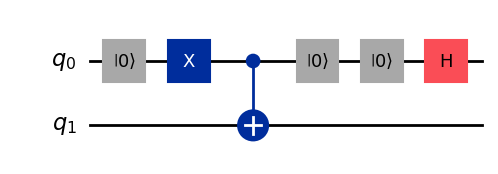

In [1]:
from qiskit import QuantumCircuit, transpile

qc = QuantumCircuit(2)
qc.reset(0)
qc.x(0)
qc.cx(0, 1)
qc.reset(0)
qc.reset(0)
qc.h(0)
qc.draw(output="mpl")

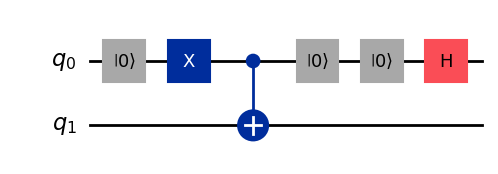

In [2]:
qc_basic_transpile = transpile(qc, optimization_level=3)
qc_basic_transpile.draw(output="mpl", style="iqp")

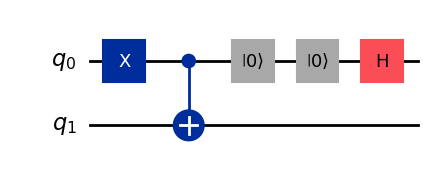

In [3]:
from qiskit.transpiler.passes.optimization.remove_reset_in_zero_state import (
    RemoveResetInZeroState,
)
from qiskit.converters import circuit_to_dag, dag_to_circuit

remove_reset = RemoveResetInZeroState()
remove_reset(qc).draw("mpl")

In [7]:
from qiskit.transpiler.basepasses import AnalysisPass


class CollectResets(AnalysisPass):
    """A local recreation of the dynacir helper pass to track reset operations."""

    def __init__(self):
        super().__init__()

    def run(self, dag):
        # We look at the Directed Acyclic Graph (DAG) representation of the circuit
        # and store the nodes containing reset instructions in the property set
        self.property_set["resets"] = dag.reset_nodes()
        return dag


# Now instantiate it exactly like the tutorial does
collect_resets = CollectResets()
print("Successfully initialized local CollectResets pass structure!")

Successfully initialized local CollectResets pass structure!


In [1]:
from dynacir.dynacir_passes import CollectResets

collect_resets = CollectResets()

In [2]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import PassManager
from dynacir.dynacir_passes import CollectResets

# 1. Grab a standard preset pass manager for your local 12-qubit backend
# We use GenericBackendV2 to build our offline target
from qiskit.providers.fake_provider import GenericBackendV2

backend_12q = GenericBackendV2(num_qubits=12)

pm = generate_preset_pass_manager(optimization_level=3, backend=backend_12q)

# 2. Manually append our custom offline CollectResets pass to the optimization stage
# This achieves exactly what the plugin does without needing an active internet connection!
pm.optimization.append(CollectResets())

# 3. Run the optimized compilation pipeline on your circuit
# Replace 'qc' with whatever your target QuantumCircuit object is named
if "sample_qc" in locals():
    qc_dynacir = pm.run(sample_qc)
    print("Circuit optimization pipeline successfully executed offline!")

    # 4. Draw the final transpiled circuit layout
    # (Note: style='iqp' is a clean visual theme for displaying mid-circuit measurements)
    qc_dynacir.draw(output="mpl", style="iqp")
else:
    print(
        "Please ensure your target circuit object is defined in this cell before running."
    )

Please ensure your target circuit object is defined in this cell before running.


Circuit optimization pipeline successfully executed offline!
Target circuit 'local_dynamic_circuit' is fully transpiled for the 12-qubit backend.


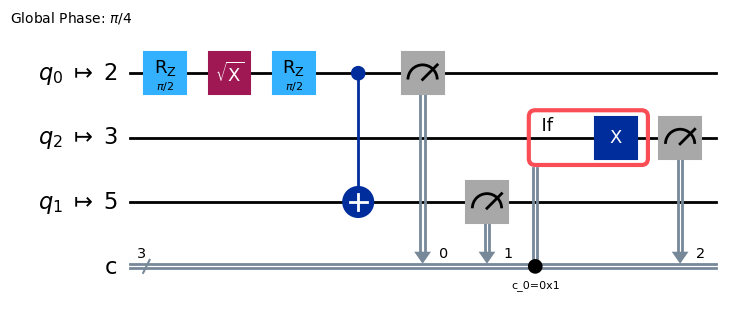

In [5]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.providers.fake_provider import GenericBackendV2
from dynacir.dynacir_passes import CollectResets

# ==========================================
# 1. DEFINE THE TARGET CIRCUIT OBJECT IN-CELL
# ==========================================
qr = QuantumRegister(3, name="q")
cr = ClassicalRegister(3, name="c")
qc_dynamic = QuantumCircuit(qr, cr, name="local_dynamic_circuit")

# Build dynamic logic: Hadamard, mid-circuit measure, and conditional operation
qc_dynamic.h(qr[0])
qc_dynamic.cx(qr[0], qr[1])
qc_dynamic.measure(qr[0], cr[0])

# Apply conditional X gate based on the mid-circuit measurement outcome
with qc_dynamic.if_test((cr[0], 1)):
    qc_dynamic.x(qr[2])

# Final measurement step
qc_dynamic.measure(qr[1], cr[1])
qc_dynamic.measure(qr[2], cr[2])


# ==========================================
# 2. INITIALIZE THE OFFLINE TARGET BACKEND
# ==========================================
# Enable control_flow support explicitly so the compiler accepts 'if_else'
backend_12q = GenericBackendV2(num_qubits=12, control_flow=True)


# ==========================================
# 3. BUILD AND RUN THE COMPILATION PIPELINE
# ==========================================
# Generate a preset manager with high optimization
pm = generate_preset_pass_manager(optimization_level=3, backend=backend_12q)

# Manually append our custom offline CollectResets pass to the optimization stage
collect_resets = CollectResets()
pm.optimization.append(collect_resets)

# Execute the compilation pipeline on our defined circuit
qc_dynacir = pm.run(qc_dynamic)

print("Circuit optimization pipeline successfully executed offline!")
print(
    f"Target circuit '{qc_dynacir.name}' is fully transpiled for the 12-qubit backend."
)

# ==========================================
# 4. VISUALIZE THE OUTPUT
# ==========================================
# Draw the final transpiled circuit layout using the clean 'iqp' theme
qc_dynacir.draw(output="mpl", style="iqp")

In [8]:
from qiskit_aer.primitives import SamplerV2

# 1. Initialize the Aer Sampler primitive cleanly
sampler = SamplerV2()

# 2. Queue the transpiled circuit for execution
job = sampler.run([qc_dynacir], shots=1024)
result = job.result()

# 3. Extract the classical register bitstring distribution data
pub_result = result[0]
counts = pub_result.data.c.get_counts()

# 4. Display the local execution results
print("--- Local Dynamic Circuit Bitstring Distribution ---")
for bitstring, count in sorted(counts.items()):
    print(f"Bitstring '{bitstring}': {count} occurrences")

--- Local Dynamic Circuit Bitstring Distribution ---
Bitstring '000': 547 occurrences
Bitstring '111': 477 occurrences
